# Design a neural Network for classifying news wires (Multi class classification) using Reuters dataset.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import reuters

# Load the Reuters dataset. This dataset contains 11,228 news wires,
# categorized into 46 different topics.
# Like IMDB, reviews are pre-processed into sequences of integers (word IDs).
# We're keeping the 10,000 most frequent words.
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
# The Reuters dataset has 46 distinct news categories.
num_classes = max(train_labels) + 1
print(f"  Number of news categories (classes): {num_classes}")

  Number of news categories (classes): 46


In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# News wires have different lengths. Neural networks need inputs of the same size.
# We'll make all news wires exactly 200 words long.
# 'padding='post'' means add zeros to the end of shorter sequences.
# 'truncating='post'' means cut off longer sequences from the end.
max_newswire_length = 200
train_data = pad_sequences(train_data, maxlen=max_newswire_length, padding='post', truncating='post')
test_data = pad_sequences(test_data, maxlen=max_newswire_length, padding='post', truncating='post')

In [6]:
from tensorflow.keras.utils import to_categorical # For one-hot encoding labels

# For multi-class classification, our labels (categories) need to be
# "one-hot encoded". This means converting a single number (e.g., category 3)
# into a vector where only the position for that category is 1, and others are 0.
# Example: category 3 (out of 46) becomes [0, 0, 0, 1, 0, ..., 0]
train_labels_one_hot = to_categorical(train_labels, num_classes=num_classes)
test_labels_one_hot = to_categorical(test_labels, num_classes=num_classes)

print(f"  Training news data shape: {train_data.shape}") # (8982 news wires, 200 words per wire)
print(f"  Training labels (one-hot) shape: {train_labels_one_hot.shape}") # (8982 labels, 46 categories)
print(f"  Example of a prepped news wire (first 10 word IDs): {train_data[0][:10]}")
print(f"  Example of its original label: {train_labels[0]}")
print(f"  Example of its one-hot encoded label: {train_labels_one_hot[0]}")

  Training news data shape: (8982, 200)
  Training labels (one-hot) shape: (8982, 46)
  Example of a prepped news wire (first 10 word IDs): [  1   2   2   8  43  10 447   5  25 207]
  Example of its original label: 3
  Example of its one-hot encoded label: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

# --- Step 2: Design Our Neural Network ---

# Define some key sizes for our network layers
vocab_size = 10000       # The total number of unique words we are considering
embedding_dim = 128      # The size of the numerical vector that will represent each word

# We build our neural network layer by layer using Keras's Sequential model.
model = Sequential([
    # Layer 1: Embedding Layer
    # This layer takes our word IDs and turns them into dense, meaningful numerical vectors (embeddings).
    # Words with similar meanings will have similar vectors.
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_newswire_length),

    # Layer 2: Global Average Pooling Layer
    # After embedding, each news wire is a sequence of 200 word vectors.
    # This layer simply averages all those word vectors to get one single, fixed-size
    # summary vector for the entire news wire. This helps simplify the input for the next layers.
    GlobalAveragePooling1D(),

    # Layer 3: Hidden Dense Layer
    # This is a standard "fully connected" layer. It learns complex patterns from the
    # averaged news wire vector.
    # '64' means it has 64 "neurons" or processing units.
    # 'activation='relu'' is a common "activation function" that helps the network learn
    # non-linear relationships (it outputs the input if positive, 0 otherwise).
    Dense(64, activation='relu'),

    # Layer 4: Output Dense Layer
    # This is our final decision-making layer for multi-class classification.
    # 'num_classes' (46) means it has 46 neurons, one for each news category.
    # 'activation='softmax'' squashes the outputs to be probabilities that sum to 1.
    # The neuron with the highest probability indicates the predicted category.
    Dense(num_classes, activation='softmax')
])

# Print a summary of the model's layers, output shapes, and number of parameters.
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# --- Step 3: Prepare the Network for Training (Compilation) ---

# Before training, we need to configure our model:
# 'optimizer='adam'': This is the algorithm that adjusts the network's internal settings (weights)
#                     during training to minimize the 'loss'. Adam is a popular and effective choice.
# 'loss='categorical_crossentropy'': This is the "cost function" or "error function". For multi-class
#                                    classification with one-hot encoded labels, this is the standard choice.
#                                    It measures how "wrong" our probability distribution prediction is.
# 'metrics=['accuracy']': This tells Keras to calculate and report the 'accuracy' during training.
#                         Accuracy is simply the percentage of correct predictions.
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
# --- Step 4: Train Our Network! ---

# This is where the model learns from the training data.
# 'train_data': The news wires (input features).
# 'train_labels_one_hot': The correct one-hot encoded category for each news wire (target labels).
# 'epochs=20': The model will go through the entire training dataset 20 times.
#              We might need more epochs for multi-class classification.
# 'batch_size=64': The model will process 64 news wires at a time before updating its weights.
# 'validation_split=0.2': We set aside 20% of our 'train_data' to use as a "validation set".
#                         The model does NOT train on this data, but its performance on this
#                         set is monitored during training. This helps us detect "overfitting".
# 'verbose=1': Shows detailed progress during training.
history = model.fit(train_data,
                    train_labels_one_hot,
                    epochs=20,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.3488 - loss: 2.8421 - val_accuracy: 0.4608 - val_loss: 2.0883
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4670 - loss: 2.0429 - val_accuracy: 0.5543 - val_loss: 1.8046
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5741 - loss: 1.7455 - val_accuracy: 0.6439 - val_loss: 1.5494
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6590 - loss: 1.4985 - val_accuracy: 0.6739 - val_loss: 1.3669
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6941 - loss: 1.3107 - val_accuracy: 0.6989 - val_loss: 1.2718
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7249 - loss: 1.1752 - val_accuracy: 0.7206 - val_loss: 1.1881
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7379 - loss: 1.0960 - val_accuracy: 0.7412 - val_loss: 1.1571
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7670 - loss: 0.9943 - val_accu

In [10]:
# --- Step 5: Evaluate Our Network (How Good Is It?) ---

# After training, we evaluate the model on the 'test_data' and 'test_labels_one_hot'.
# This data was completely unseen by the model during training, giving us an unbiased
# measure of how well it generalizes to new news wires.
# 'verbose=2': Shows only the final loss and accuracy, no progress bar.
loss, accuracy = model.evaluate(test_data, test_labels_one_hot, verbose=2)

print(f"\nFinal Test Loss: {loss:.4f}")       # The average error on the test set
print(f"Final Test Accuracy: {accuracy:.4f}") # The percentage of correct predictions on the test set

71/71 - 0s - 3ms/step - accuracy: 0.7965 - loss: 0.9440

Final Test Loss: 0.9440
Final Test Accuracy: 0.7965


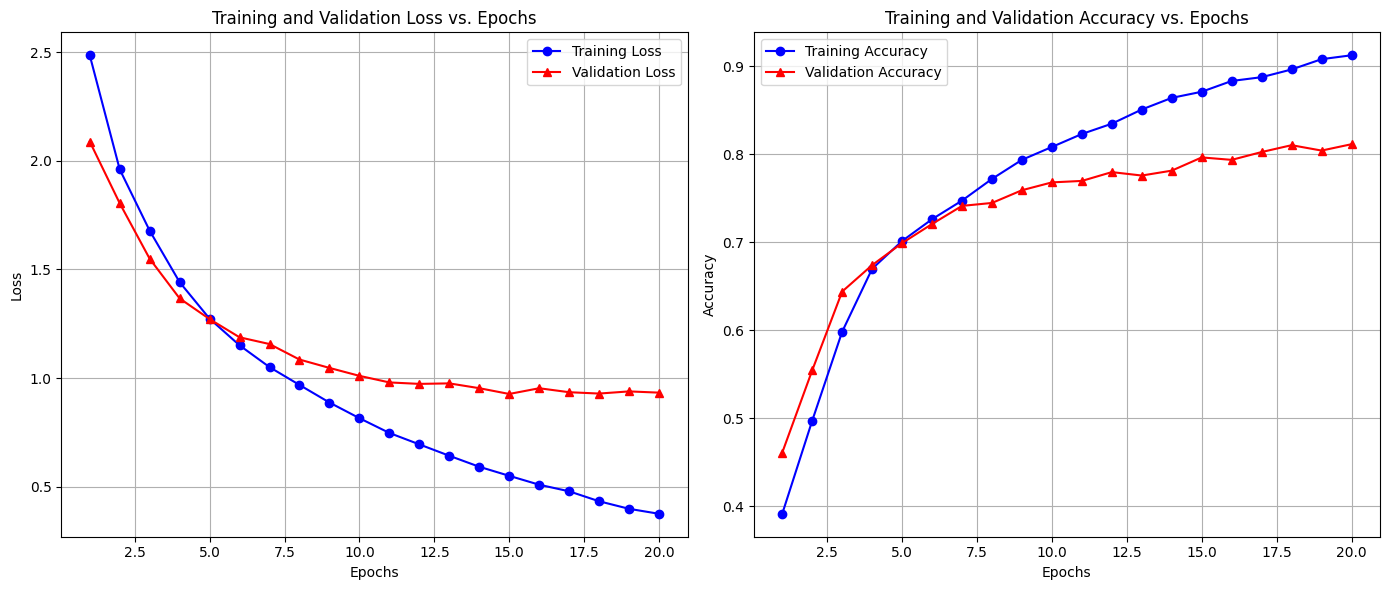


Plots displayed. Observe how the training and validation lines behave.
If the validation loss starts increasing significantly while training loss decreases,
it's a sign of overfitting. Similarly, if validation accuracy stops improving or drops,
while training accuracy keeps rising, it's also overfitting.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 6: Visualize Training Progress (Graphs!) ---

# The 'history' object contains all the metrics recorded during training.
history_dict = history.history

# Extract training and validation accuracy and loss values
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

# Create a list of epoch numbers for the x-axis of our plots
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6)) # Set the size of the entire figure

# --- Graph 1: Training and Validation Loss vs. Epochs ---
plt.subplot(1, 2, 1) # This means: 1 row, 2 columns, this is the 1st plot
plt.plot(epochs, loss, 'bo-', label='Training Loss') # 'bo-' for blue circles and lines
plt.plot(epochs, val_loss, 'r^-', label='Validation Loss') # 'r^-' for red triangles and lines
plt.title('Training and Validation Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend() # Show the labels (Training Loss, Validation Loss)
plt.grid(True) # Add a grid for readability

# --- Graph 2: Training and Validation Accuracy vs. Epochs ---
plt.subplot(1, 2, 2) # This means: 1 row, 2 columns, this is the 2nd plot
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r^-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust subplots to give a nice tight layout
plt.show() # Display the plots

print("\nPlots displayed. Observe how the training and validation lines behave.")
print("If the validation loss starts increasing significantly while training loss decreases,")
print("it's a sign of overfitting. Similarly, if validation accuracy stops improving or drops,")
print("while training accuracy keeps rising, it's also overfitting.")

In [16]:
# --- Example: Making a Prediction on a single news wire ---

# Let's take the first news wire from our test dataset and see what the model predicts.
# We need to reshape it to be a "batch" of 1 news wire for the model.
sample_newswire_for_prediction = test_data[46:47] # Select the first news wire and keep its batch dimension
true_category_label = test_labels[46] # Original integer label

# Get the model's prediction (a probability distribution over all 46 categories)
prediction_probabilities = model.predict(sample_newswire_for_prediction)[0]

# The predicted category is the one with the highest probability
predicted_category = np.argmax(prediction_probabilities)

print(f"  Actual category for the first test news wire (ID): {true_category_label}")
print(f"  Model's predicted category (ID): {predicted_category}")
print(f"  Confidence for predicted category: {prediction_probabilities[predicted_category]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
  Actual category for the first test news wire (ID): 3
  Model's predicted category (ID): 3
  Confidence for predicted category: 0.9890
